In [50]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from single_qubit_pyscrip_v1_1 import system_cfg
from single_qubit_pyscrip_v1_1.system_tool import select_config_idx
from qick.asm_v2 import QickSpan, QickSweep1D
soc, soccfg = system_cfg.soc, system_cfg.soccfg


Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_53c60f15ee6b4e639f9023a9c5fc81c9@192.168.10.113:45141
QICK running on ZCU216, software version 0.2.342

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - enve

In [55]:
from YOKOGS200 import YOKOGS200
import pyvisa 
rm = pyvisa.ResourceManager()
yoko_connect='USB0::0x0B21::0x0039::91T810992::INSTR'
yoko = YOKOGS200(yoko_connect, rm)
yoko.GetCurrent()

-0.002

# Qubit setting

In [12]:
# Define the qubit index
qubit_idx=3

config={**system_cfg.hw_cfg,**system_cfg.readout_cfg, **system_cfg.qubit_cfg, **system_cfg.expt_cfg}

# TOF

  0%|          | 0/2000 [00:00<?, ?it/s]

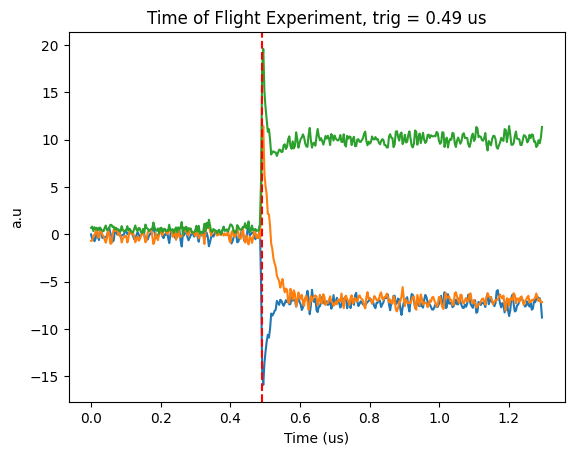

In [17]:
from single_qubit_pyscrip_v1_1.s001_time_of_flight import TOF

run_cfg = select_config_idx(config, qubit_idx)
run_cfg.update({
    'ro_length':1.3,
    'res_legnth':0.2,
    'res_gain_ge':1,
    'soft_avg':2000
})

tof = TOF(soc, soccfg, run_cfg)
tof.run(2000)
tof.plot()

config['trig_time']=0.49

# Resonator OneTone

c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\single_qubit_pyscrip_v1_1\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': 5.7988, 'Qi': 7110, 'Ql': 348, 'absQc': 365, 'κ(MHz)': 16.68}


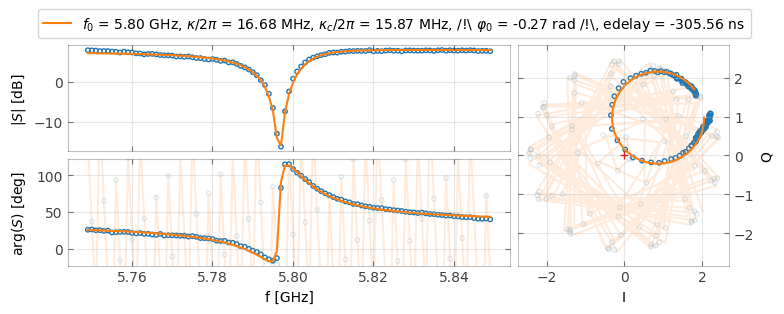

In [67]:
from single_qubit_pyscrip_v1_1.s002_res_spec_ge import Resonator_onetone

START_FREQ = config['res_freq_ge'][qubit_idx]- 50  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 50   # [MHz]
STEPS = 101


config['res_gain_ge'][qubit_idx] = 0.1
run_cfg = select_config_idx(config, qubit_idx)

run_cfg.update([('steps', STEPS),
                ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('relax_delay', 1),
                ('cooling', False)
                ])

onetone = Resonator_onetone(soc, soccfg, run_cfg)
# onetone.run(py_avg=10)
fres = onetone.run(py_avg=10, liveplot=True)
# result = onetone.plot_circle()
## update value ##
config['res_freq_ge'][qubit_idx] = round(fres[0]/1e6,4)
# onetone.saveLabber(qubit_idx, save_sim=True)

average count:   0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

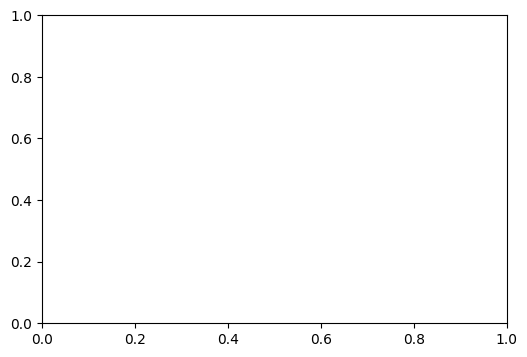

In [ ]:
from single_qubit_pyscrip_v1_1.s002b_res_punchout_ge import SingleToneSpectroscopyPunchout

run_cfg = select_config_idx(config, qubit_idx)

START_FREQ = config['res_freq_ge'][qubit_idx]- 3  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 3   # [MHz]
STEPS_freq = 101

START_gain = 0.01  # [MHz]
STOP_gain = 0.7  # [MHz]
STEPS_gain = 61
run_cfg.update([('f_steps', STEPS_freq), ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
               ('g_steps', STEPS_gain), ('res_gain_ge', QickSweep1D('gainloop', START_gain, STOP_gain))])
punchout = SingleToneSpectroscopyPunchout(soc, soccfg, run_cfg)
punchout.run(py_avg=50, liveplot=True)
punchout.saveLabber(qubit_idx)

# Onetone Flux

## Yokogawa

In [ ]:
from YOKOGS200 import YOKOGS200
import pyvisa 
rm = pyvisa.ResourceManager()
yoko_connect='USB0::0x0B21::0x0039::91T810992::INSTR'
yoko = YOKOGS200(yoko_connect, rm)
yoko.GetCurrent()

-0.000414

Data save to C:\Users\QEL\Desktop\2DQ12\yokotest\2025\06\Data_0619\s002_onetone_flux_Q3_4


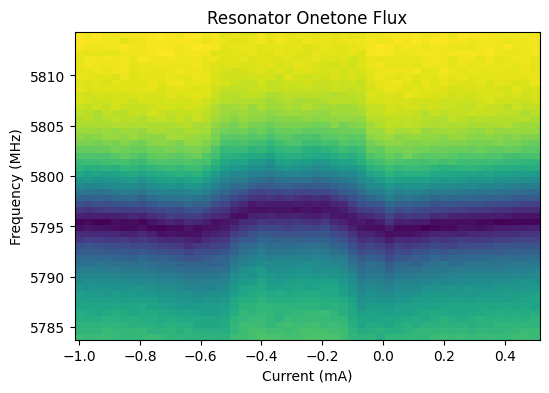

In [60]:
from single_qubit_pyscrip_v1_1.s002c_res_spec_ge_flux import Resonator_onetone_flux

run_cfg = select_config_idx(config, qubit_idx)


START_FREQ = config['res_freq_ge'][qubit_idx]- 15  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 15   # [MHz]
STEPS = 51
Start_flux = -1 # [mA]
Stop_flux = 0.5 # [mA]
Steps_flux = 51
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux)*1e-3
run_cfg.update([('steps', STEPS),
                ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('relax_delay', 1)
                ])

onetone_flux = Resonator_onetone_flux(soc, soccfg, run_cfg)
onetone_flux.liveplot_yoko(10, yoko_range, yoko_connect)
onetone_flux.saveLabber(qubit_idx, yoko_range)

In [66]:
yoko.SetCurrent(-0.32e-3)

## Hardware loop

In [ ]:
from single_qubit_pyscrip_v1_1.s002c_res_spec_ge_flux import Resonator_onetone_flux

run_cfg = select_config_idx(config, qubit_idx)

START_FREQ = 5000
STOP_FREQ = 6000
STEPS = 101
yoko_range = np.linspace(0, 1, 21)*1e-3
run_cfg.update([('steps', STEPS),
                ('steps_flux', 21),
                ('flux_ch', 2),
                ('flux_length', 10),
                ('saturate_times', 0.5),
                ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('flux_gain', QickSweep1D('fluxloop', -0.01, 0.01)),
                ('relax_delay', 1)
                ])

onetone_flux = Resonator_onetone_flux(soc, soccfg, run_cfg)
onetone_flux.liveplot_hardwre(50)

# Cooling sweep

(3224.999914741523, 2219.9994827270507)

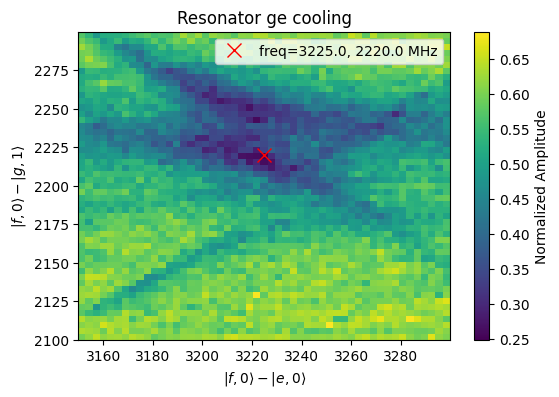

In [85]:
from single_qubit_pyscrip_v1_1.s002d_res_cooling_ge import SingleToneSpectroscopyCooling

run_cfg = select_config_idx(config, qubit_idx)

START_FREQ_1 =  3150 # [MHz]
STOP_FREQ_1 =   3300 # [MHz]
STEPS_freq_1 = 51

START_FREQ_2 =  2100 # [MHz]
STOP_FREQ_2 =   2300 # [MHz]
STEPS_freq_2 = 51

config.update([
    ('cool_ch1', 5), ('cool_gain_1',0.5), ('nqz_cool_ch1', 2), ('cool_mixer1', 3000),
    ('cool_ch2', 2), ('cool_gain_2',0.5), ('nqz_cool_ch2', 2), ('cool_mixer2', 2000),
    ('cool_length', 1)])

run_cfg.update([('f_steps1', STEPS_freq_1), ('cool_freq_1', QickSweep1D('freqloop1', START_FREQ_1, STOP_FREQ_1)),
               ('f_steps2', STEPS_freq_2), ('cool_freq_2', QickSweep1D('freqloop2', START_FREQ_2, STOP_FREQ_2)),
               ('cool_ch1', 5), ('cool_gain_1',0.5), ('nqz_cool_ch1', 2), ('cool_mixer1', 3000),
               ('cool_ch2', 2), ('cool_gain_2',0.5), ('nqz_cool_ch2', 2), ('cool_mixer2', 2000),
               ('cool_length', 1)])
cooling = SingleToneSpectroscopyCooling(soc, soccfg, run_cfg)
cooling.run(py_avg=10, liveplot=True)
# cooling.saveLabber(qubit_idx)

In [86]:
config.update([
    ('cool_ch1', 5), ('cool_freq_1', 3225), ('cool_gain_1', 0.1), ('nqz_cool_ch1', 2), ('cool_mixer1', 3000),
    ('cool_ch2', 2), ('cool_freq_2', 2220), ('cool_gain_2', 0.5), ('nqz_cool_ch2', 2), ('cool_mixer2', 2000),
    ('cool_length', 2)])


# Qubit Spectrum ge

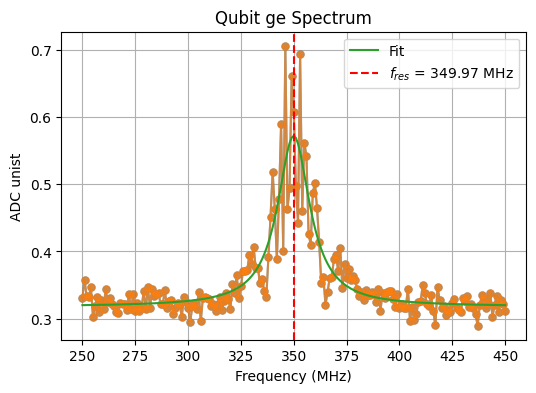

In [87]:
from single_qubit_pyscrip_v1_1.s003_qubit_spec_ge import Qubit_Twotone

run_cfg = select_config_idx(config, qubit_idx)

cemter = 350
SPAN = 100
START_FREQ = cemter - SPAN # [MHz]
STOP_FREQ = cemter + SPAN  # [MHz]
STEPS = 201

config['nqz_qubit'] = 1
run_cfg.update([('steps', STEPS), 
                ('qubit_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('qmixer_freq',cemter),
                ('qubit_gain_ge', 0.1),
                # ('res_gain_ge', 0.2),
                ('qubit_length_ge', 1.0),
                ('relax_delay',1),
                ('cooling', True)
                ])

spectrum_ge = Qubit_Twotone(soc, soccfg, run_cfg)
f_ge = spectrum_ge.run(30, liveplot=True)
# f_ge = spectrum_ge.plot()
config['qubit_freq_ge'][qubit_idx] = f_ge
config['qmixer_freq'][qubit_idx] = f_ge
# spectrum_ge.saveLabber(qubit_idx, save_sim=True)

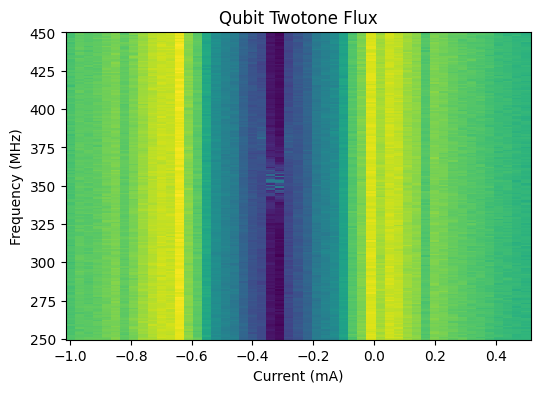

In [ ]:
from single_qubit_pyscrip_v1_1.s003a_qubit_flux_spec_ge import Qubit_Twotone_Flux

run_cfg = select_config_idx(config, qubit_idx)

cemter = 350
SPAN = 100
START_FREQ = cemter - SPAN # [MHz]
STOP_FREQ = cemter + SPAN  # [MHz]
STEPS = 201

Start_flux = -1 # [mA]
Stop_flux = 0.5 # [mA]
Steps_flux = 51
yoko_range = np.linspace(Start_flux, Stop_flux, Steps_flux)*1e-3

config['nqz_qubit'] = 1
run_cfg.update([('steps', STEPS), 
                ('qubit_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('qmixer_freq',cemter),
                ('qubit_gain_ge', 0.1),
                # ('res_gain_ge', 0.2),
                ('qubit_length_ge', 1.0),
                ('relax_delay',1),
                ('cooling', False)
                ])

spectrum_ge_flux = Qubit_Twotone_Flux(soc, soccfg, run_cfg)
spectrum_ge_flux.liveplot_yoko(30, yoko_range, yoko_connect)

# Power Rabi ge

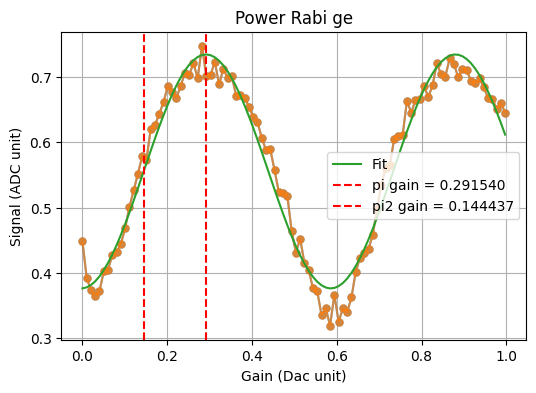

In [121]:
from single_qubit_pyscrip_v1_1.s005_power_rabi_ge import Amp_Rabi


START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100

config["sigma"][qubit_idx] = 0.02
config['relax_delay'] = 1
run_cfg = select_config_idx(config, qubit_idx)

run_cfg.update([
    ('steps', STEPS), 
    ('qubit_gain_ge',QickSweep1D('gainloop', START_GAIN, STOP_GAIN)),
    ('cooling', True)
    ])

prabi = Amp_Rabi(soc, soccfg, run_cfg)
config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.run(30, liveplot=True)
# config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.plot()
# prabi.saveLabber(qubit_idx)

# Ramsey

Detune < 5kHz


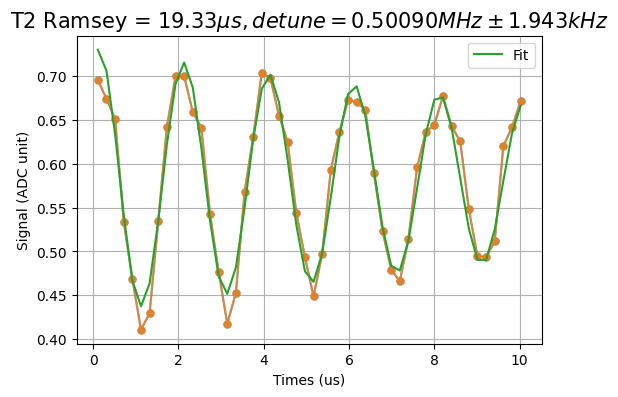

In [122]:
from single_qubit_pyscrip_v1_1.s006_Ramsey_ge import Ramsey

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 10  # [us]
STEPS = 50
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('ramsey_freq', 0.5),
    ('cooling', True)
    ])

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(30, liveplot=True)
# t2r.plot()
config['qubit_freq_ge'][qubit_idx] = t2r.correct_detune()
# t2r.saveLabber(qubit_idx, 0, save_sim=True)


# Echo

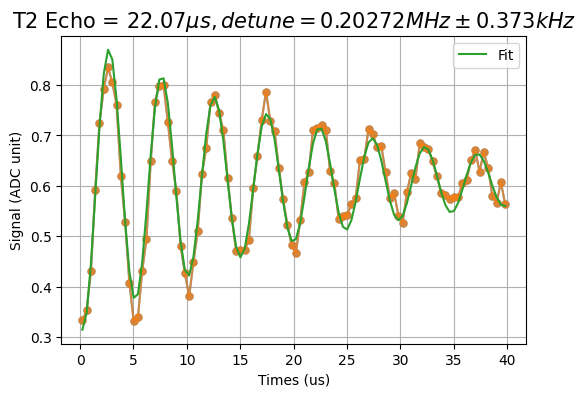

In [77]:
from single_qubit_pyscrip_v1_1.s007_SpinEcho_ge import SpinEcho

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 40  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('ramsey_freq', 0.2),
    ('cooling', True)
    ])

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(20, liveplot=True)
# t2e.plot()
# t2e.saveLabber(qubit_idx, 0, save_sim=True)

# T1

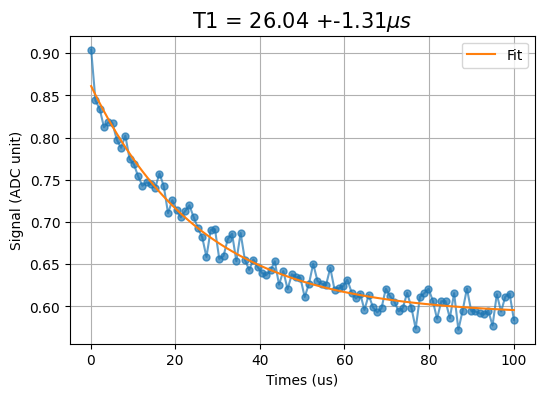

In [78]:
from single_qubit_pyscrip_v1_1.s008_T1_ge import T1

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 100  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('relax_delay', 1),
    ('cooling', True)
    ])

t1 = T1(soc, soccfg, run_cfg)
t1.run(30, liveplot=True)


# t1.saveLabber(qubit_idx, 0, save_sim=True)

# Single shot

# Cooling to e

In [ ]:
from single_qubit_pyscrip_v1_1.s002d_res_cooling_ge import SingleToneSpectroscopyCooling

run_cfg = select_config_idx(config, qubit_idx)

START_FREQ_1 =  3150 # [MHz]
STOP_FREQ_1 =   3300 # [MHz]
STEPS_freq_1 = 51

START_FREQ_2 =  1900 # [MHz]
STOP_FREQ_2 =   2050 # [MHz]
STEPS_freq_2 = 51

config.update([
    ('cool_ch1', 5), ('cool_gain_1',0.8), ('nqz_cool_ch1', 2), ('cool_mixer1', 3000),
    ('cool_ch2', 2), ('cool_gain_2',0.4), ('nqz_cool_ch2', 2), ('cool_mixer2', 2000),
    ('cool_length', 1)])

run_cfg.update([('f_steps1', STEPS_freq_1), ('cool_freq_1', QickSweep1D('freqloop1', START_FREQ_1, STOP_FREQ_1)),
               ('f_steps2', STEPS_freq_2), ('cool_freq_2', QickSweep1D('freqloop2', START_FREQ_2, STOP_FREQ_2))
               ])
punchout = SingleToneSpectroscopyCooling(soc, soccfg, run_cfg)
punchout.run(py_avg=20, liveplot=True)
# punchout.saveLabber(qubit_idx)

# Onetone EF

c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\single_qubit_pyscrip_v1_1\abcd_rf_fit\abcd_rf_fit.py:187: UserWarning: Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False
  warnings.warn("Extracted phi_0 greater than 0.25, this might indicate a big impedance mismatch, values of kappa_i and kappa_c might be affected, you can try to set: allow_mismatch=False", UserWarning)


{'Fres(GHz)': 5.7983, 'Qi': 11047, 'Ql': 342, 'absQc': 353, 'κ(MHz)': 16.94}


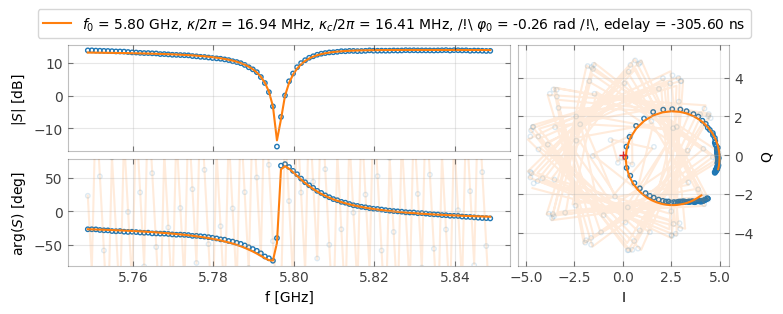

In [126]:
from single_qubit_pyscrip_v1_1.s009_res_spec_ef import Resonator_onetone_ef


run_cfg = select_config_idx(config, qubit_idx)

START_FREQ = config['res_freq_ge'][qubit_idx]- 50  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 50   # [MHz]
STEPS = 101
run_cfg.update([('steps', STEPS), 
                ('res_freq_ef', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('res_gain_ef',0.2),
                ('cooling', False)
                ])

onetone_ef = Resonator_onetone_ef(soc, soccfg, run_cfg)
# onetone.run(py_avg=10)
fres = onetone_ef.run(py_avg=10, liveplot=True)
# result = onetone.plot_circle()
## update value ##
config['res_freq_ef'][qubit_idx] = round(fres[0]/1e6,4)
# config['res_freq_ef'][qubit_idx] = config['res_freq_ge'][qubit_idx]
# onetone_ef.saveLabber(qubit_idx, save_sim=True)|

# Qubit Spectrum ef

Data save to C:\Users\QEL\Desktop\2DQ12\yokotest\2025\06\Data_0619\s010_qubit_spec_ef_Q3_1


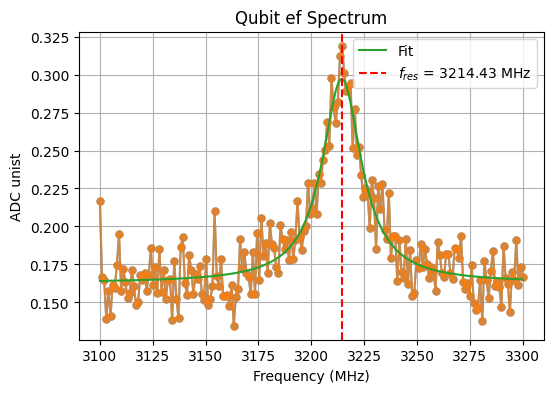

In [127]:
from single_qubit_pyscrip_v1_1.s010_qubit_spec_ef import Qubit_Twotone_ef

run_cfg = select_config_idx(config, qubit_idx)

cemter = 3200
SPAN = 100
START_FREQ = cemter - SPAN # [MHz]
STOP_FREQ = cemter + SPAN  # [MHz]
STEPS = 200

config['qubit_ch_ef'][qubit_idx] = 3


config.update([
    ('nqz_qubit_ef', 2),
])
run_cfg.update([('steps', STEPS),
                ('qubit_freq_ef', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('qmixer_freq_ef', 3000),
                ('qubit_gain_ef', 0.2),
                ('nqz_qubit_ef', 2),
                ('relax_delay', 1),
                ('cooling', True),
                ('ge_ref', True),
                ])

spectrum_ge = Qubit_Twotone_ef(soc, soccfg, run_cfg)
f_ef = spectrum_ge.run(20, liveplot=True)
config['qubit_freq_ef'][qubit_idx] = f_ef
config['qmixer_freq_ef'][qubit_idx] = f_ef
spectrum_ge.saveLabber(qubit_idx, save_sim=True)

# Rabi EF

KeyboardInterrupt: 

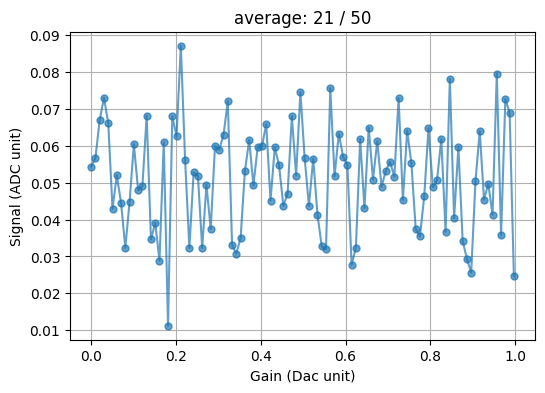

In [130]:
from single_qubit_pyscrip_v1_1.s011_power_rabi_ef import Amp_Rabi_ef


START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100


config["sigma_ef"][qubit_idx] = 0.02
config['relax_delay'] = 1
run_cfg = select_config_idx(config, qubit_idx)

run_cfg.update([
    ('steps', STEPS), 
    ('qubit_gain_ef',QickSweep1D('gainloop', START_GAIN, STOP_GAIN)),
    ('cooling', True),
    ('ge_ref', True),
    ])

prabi = Amp_Rabi_ef(soc, soccfg, run_cfg)
config['qubit_pi_gain_ef'][qubit_idx], config['qubit_pi2_gain_ef'][qubit_idx] = prabi.run(50, liveplot=True)
# a, b = prabi.run(50, liveplot=True)
# config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.plot()
# prabi.saveLabber(qubit_idx)

# Ramsey ef

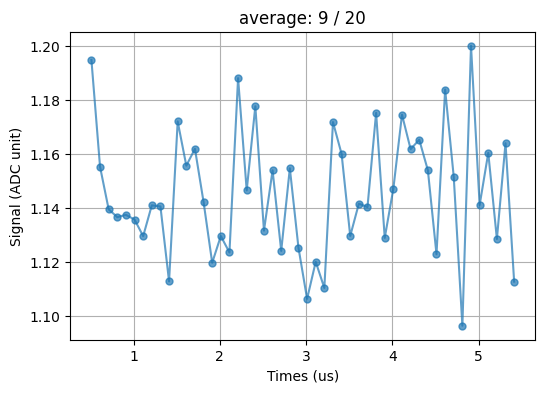

KeyboardInterrupt: 

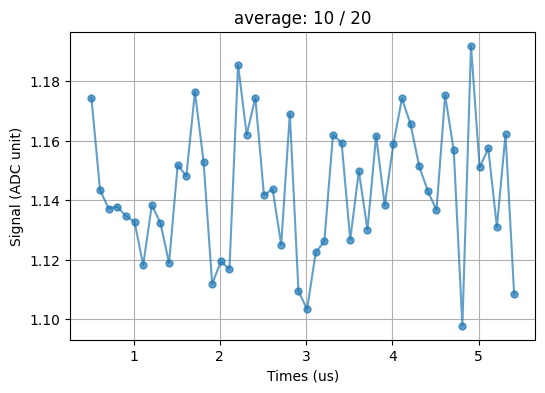

In [36]:
from single_qubit_pyscrip_v1_1.s012_Ramsey_ef import Ramsey_ef

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 5  # [us]
STEPS = 50
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('ramsey_freq', 0.2),
    ('cooling', False),
    ('ge_ref',False),
    ])

t2r_ef = Ramsey_ef(soc, soccfg, run_cfg)
t2r_ef.run(20, liveplot=True)
# tt2r_ef2r.plot()
config['qubit_freq_ef'][qubit_idx] = t2r_ef.correct_detune()
# t2r_ef.saveLabber(qubit_idx, 0, save_sim=True)


# T1 ef

c:\Users\QEL\Desktop\tprocv2_guidemo-2DQ12\single_qubit_pyscrip_v1_1\fitting.py:99: RuntimeWarning: overflow encountered in exp
  return y0 + yscale * np.exp(-(x - x0) / decay)


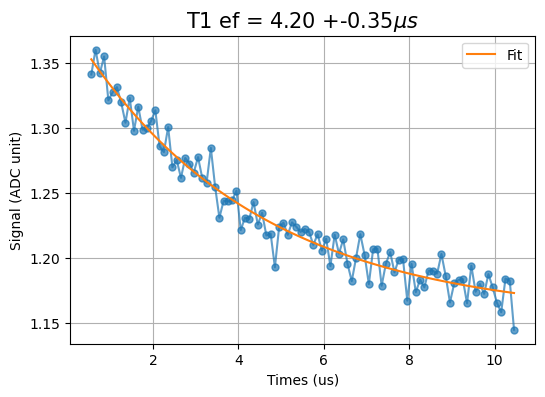

In [ ]:
from single_qubit_pyscrip_v1_1.s013_T1_ef import T1_ef

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 100  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('relax_delay', 100),
    ('cooling', False),
    ('ge_ref', True),

    ])

t1_ef = T1_ef(soc, soccfg, run_cfg)
t1_ef.run(50, liveplot=True)


# t1.saveLabber(qubit_idx, 0, save_sim=True)

# Qubit Temperature

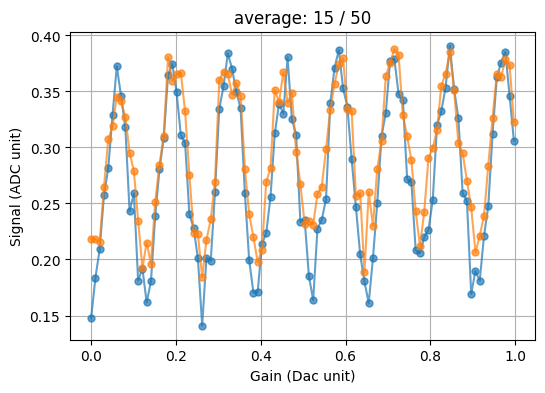

KeyboardInterrupt: 

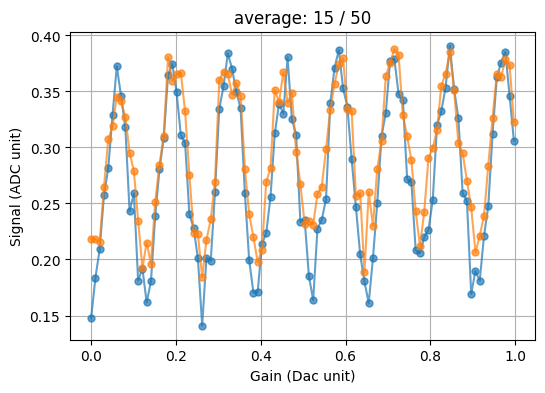

In [64]:
from single_qubit_pyscrip_v1_1.s013_qubit_temp import Qubit_temperature


START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 100


config["sigma_ef"][qubit_idx] = 0.1
config['relax_delay'] = 100
run_cfg = select_config_idx(config, qubit_idx)

run_cfg.update([
    ('steps', STEPS), 
    ('qubit_gain_ef',QickSweep1D('gainloop', START_GAIN, STOP_GAIN)),
    ('cooling', True),
    ('ge_ref', True),

    ])

prabi = Qubit_temperature(soc, soccfg, run_cfg)
# config['qubit_pi_gain_ef'][qubit_idx], config['qubit_pi2_gain_ef'][qubit_idx] = prabi.run(50, liveplot=True)
x, y =prabi.run(50, liveplot=True)
# config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.plot()
# prabi.saveLabber(qubit_idx)

# ALLXY

  0%|          | 0/21 [00:00<?, ?it/s]

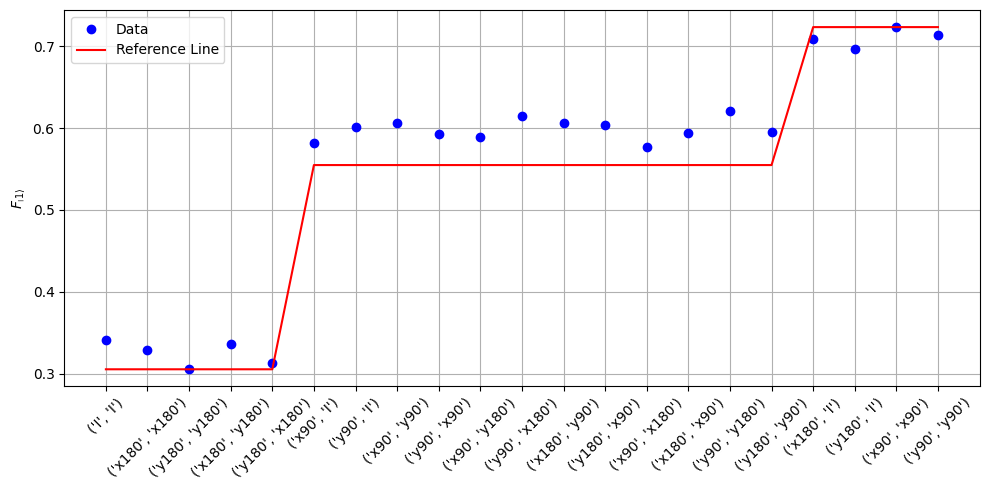

In [123]:
from single_qubit_pyscrip_v1_1.s014_AllXY import AllXY

allxy = AllXY(soc, soccfg, run_cfg)
allxy.run(50)
allxy.plot()